[Titanic: logistic regression with python](https://www.kaggle.com/code/mnassrib/titanic-logistic-regression-with-python)

Titanic dataset from kaggle: yasserh/titanic-dataset


## 載入基本套件

In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 讀取檔案
`path = kagglehub.dataset_download("yasserh/titanic-dataset")`

filename = `Titanic-Dataset.csv`

In [173]:
import kagglehub


# Download the latest version of a common Titanic dataset
path = kagglehub.dataset_download("yasserh/titanic-dataset")

# Load the CSV file (typically named 'Titanic-Dataset.csv' or similar)
# Adjust the filename based on the output of the list above
df = pd.read_csv(f"{path}/Titanic-Dataset.csv")
df.head()

Using Colab cache for faster access to the 'titanic-dataset' dataset.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 消除重複資料

In [174]:
df.duplicated().sum()

np.int64(0)

顯示沒有重複資料

## 建立資料集與分割訓練、測試資料

In [175]:
X = df.drop('Survived', axis=1)
y = df['Survived']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, t_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [176]:
print(f"訓練資料維度{X_train.shape}")
print(f"測試資料維度{X_test.shape}")

訓練資料維度(712, 11)
測試資料維度(179, 11)


## 資料前處理

In [177]:
#資料數量與維度探索
df.shape

(891, 12)

含有survived屬性

In [178]:
#檢查屬性欄位的遺失值數量
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### 處理訓練資料遺失值

In [113]:
X_train.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,140
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,553


"Age", "Cabin", "Embarked"等屬性有空值

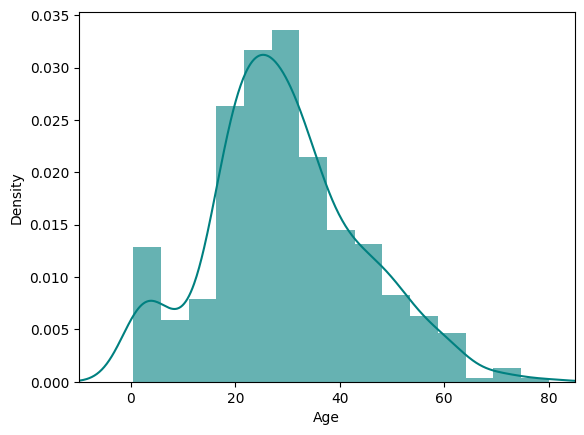

In [179]:
#檢查Age屬性資料分布
ax = X_train["Age"].hist(bins=15, density=True, stacked=True, color='teal', alpha=0.6)
X_train["Age"].plot(kind='density', color='teal')
ax.set(xlabel='Age')
plt.xlim(-10,85)
plt.show()

In [180]:
# mean age
print('Age平均值 = %.2f' %(X_train["Age"].mean(skipna=True)))
# median age
print('Age中位數 = %.2f' %(X_train["Age"].median(skipna=True)))

Age平均值 = 29.50
Age中位數 = 28.00


In [181]:
#檢查cabin(類別屬性)遺失值狀況
print('Cabin紀錄遺失值佔比 %.2f%%' %((X_train['Cabin'].isnull().sum()/X_train.shape[0])*100))

Cabin紀錄遺失值佔比 77.67%


In [182]:
#檢查Embarked(類別屬性)遺失值狀況
print('Embarked紀錄遺失值佔比 %.2f%%' %((X_train['Embarked'].isnull().sum()/X_train.shape[0])*100))

Embarked紀錄遺失值佔比 0.28%


登船乘客以登船碼頭分類 (C = Cherbourg, Q = Queenstown, S = Southampton):
Embarked
S    525
C    125
Q     60
Name: count, dtype: int64


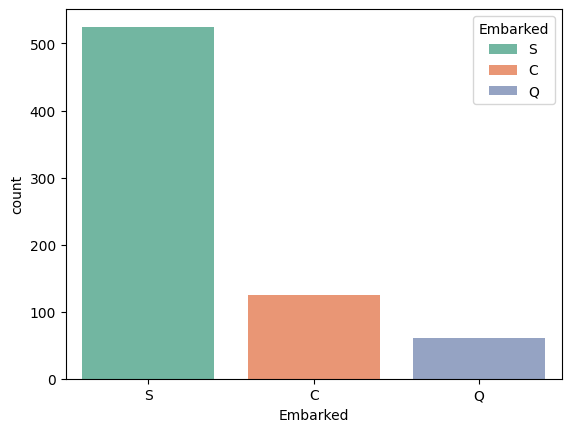

In [183]:
#上傳地點數量分析
print('登船乘客以登船碼頭分類 (C = Cherbourg, Q = Queenstown, S = Southampton):')
print(X_train['Embarked'].value_counts())
sns.countplot(x='Embarked', data=X_train, palette='Set2', hue="Embarked")
plt.show()

In [184]:
print('最常登船碼頭 %s.' %X_train['Embarked'].value_counts().idxmax())

最常登船碼頭 S.


In [185]:
#遺失值補救
X_train_adj = X_train.copy()
X_train_adj["Age"].fillna(X_train["Age"].median(skipna=True), inplace=True)
X_train_adj["Embarked"].fillna(X_train['Embarked'].value_counts().idxmax(),  inplace=True)
X_train_adj.drop('Cabin', axis=1,  inplace=True)


/tmp/ipykernel_875/3084074751.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train_adj["Age"].fillna(X_train["Age"].median(skipna=True), inplace=True)
/tmp/ipykernel_875/3084074751.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(va

In [186]:
X_train_adj.isnull().sum()


,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,0


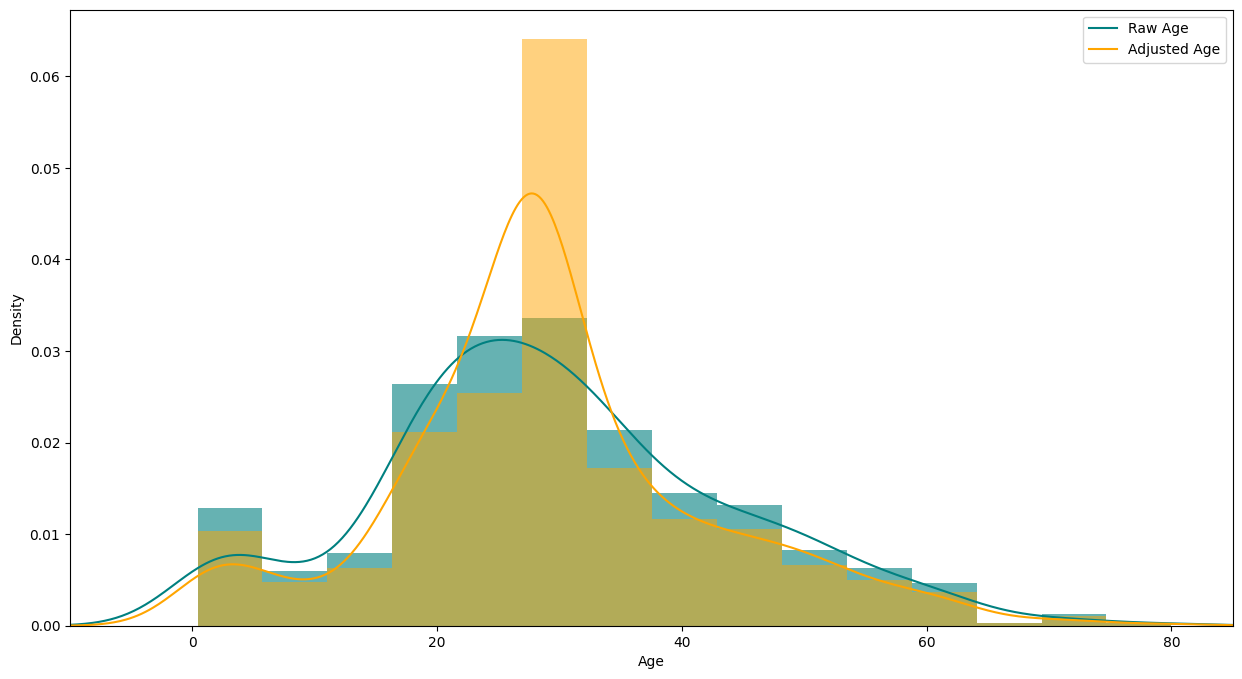

In [187]:
plt.figure(figsize=(15,8))
#原始資料-綠色
ax = X_train["Age"].hist(bins=15, density=True, stacked=True, color='teal', alpha=0.6)
X_train["Age"].plot(kind='density', color='teal')
#處理後資料-橘色
ax = X_train_adj["Age"].hist(bins=15, density=True, stacked=True, color='orange', alpha=0.5)
X_train_adj["Age"].plot(kind='density', color='orange')

ax.legend(['Raw Age', 'Adjusted Age'])
ax.set(xlabel='Age')
plt.xlim(-10,85)
plt.show()

In [188]:
feature_cols = ['Pclass',	'Sex',	'Age',	'SibSp',	'Parch',	'Fare',	'Embarked']
X_train = X_train_adj[feature_cols]
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5000,S
733,2,male,23.0,0,0,13.0000,S
382,3,male,32.0,0,0,7.9250,S
704,3,male,26.0,1,0,7.8542,S
813,3,female,6.0,4,2,31.2750,S


## 類別屬性值邊碼

In [190]:
##類別屬性編碼
##將類別欄位轉換為 One-Hot Encoding
training=pd.get_dummies(X_train, columns=["Pclass","Embarked","Sex"])
print(training.shape)
training.head()


(712, 12)


,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
331,45.5,0,0,28.5000,True,False,False,False,False,True,False,True
733,23.0,0,0,13.0000,False,True,False,False,False,True,False,True
382,32.0,0,0,7.9250,False,False,True,False,False,True,False,True
704,26.0,1,0,7.8542,False,False,True,False,False,True,False,True
813,6.0,4,2,31.2750,False,False,True,False,False,True,True,False


## 特徵選擇

In [191]:
final_train = pd.concat([X_train, y_train], axis=1)

age存活分析

/tmp/ipykernel_875/4005661142.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(final_train["Age"][final_train.Survived == 1], color="darkturquoise", shade=True)
/tmp/ipykernel_875/4005661142.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(final_train["Age"][final_train.Survived == 0], color="lightcoral", shade=True)


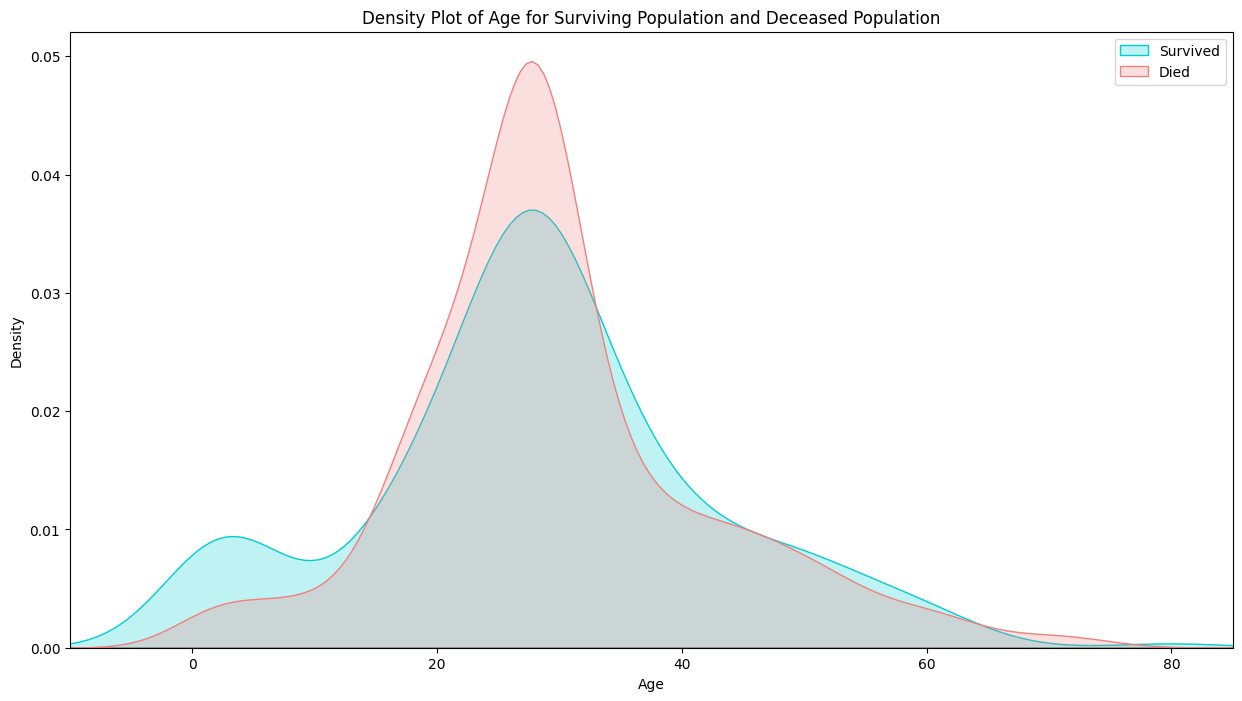

In [192]:
plt.figure(figsize=(15,8))
ax = sns.kdeplot(final_train["Age"][final_train.Survived == 1], color="darkturquoise", shade=True)
sns.kdeplot(final_train["Age"][final_train.Survived == 0], color="lightcoral", shade=True)
plt.legend(['Survived', 'Died'])
plt.title('Density Plot of Age for Surviving Population and Deceased Population')
ax.set(xlabel='Age')
plt.xlim(-10,85)
plt.show()

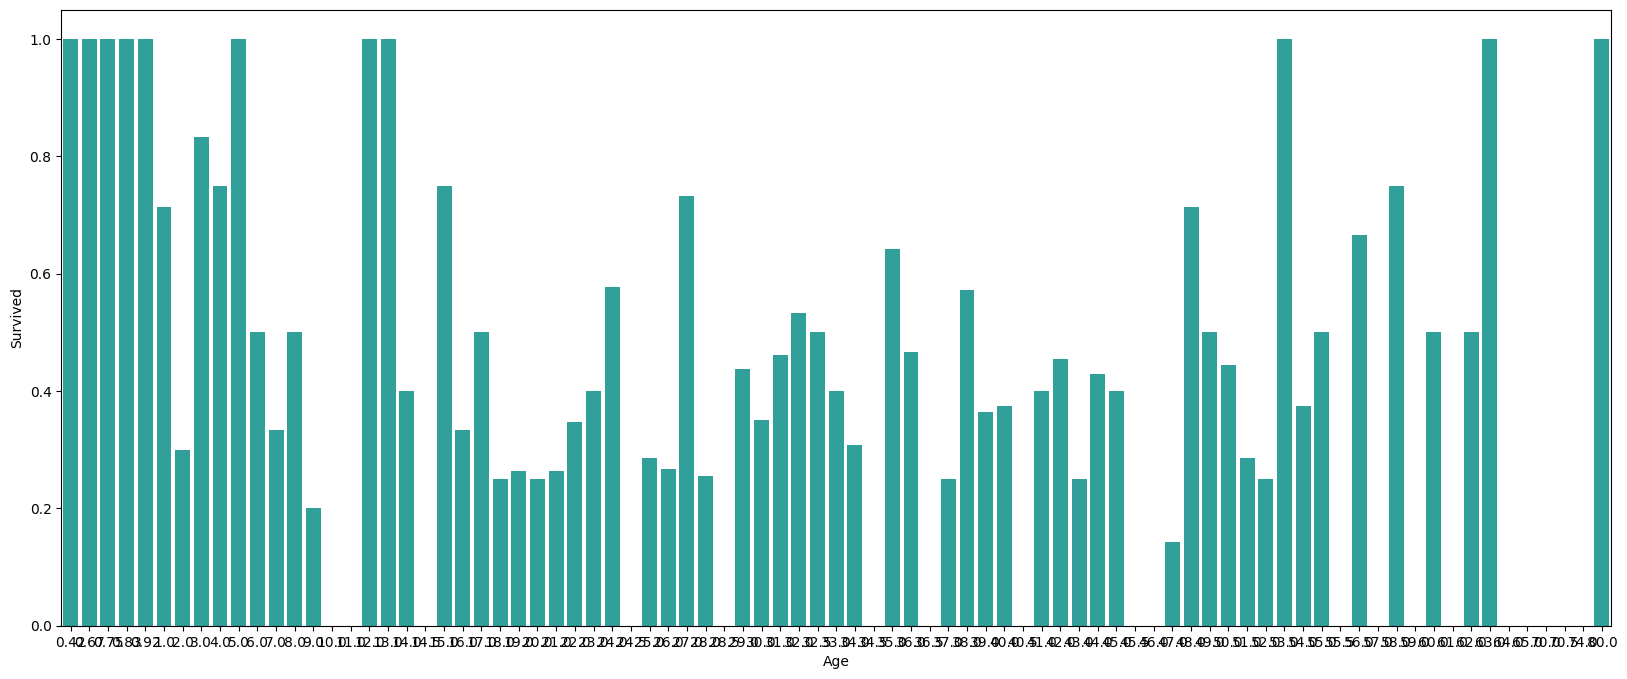

In [193]:
plt.figure(figsize=(20,8))
avg_survival_byage = final_train[["Age", "Survived"]].groupby(['Age'], as_index=False).mean()
g = sns.barplot(x='Age', y='Survived', data=avg_survival_byage, color="LightSeaGreen")
plt.show()

Fare存活分析

/tmp/ipykernel_875/4068214424.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(final_train["Fare"][final_train.Survived == 1], color="darkturquoise", shade=True)
/tmp/ipykernel_875/4068214424.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(final_train["Fare"][final_train.Survived == 0], color="lightcoral", shade=True)


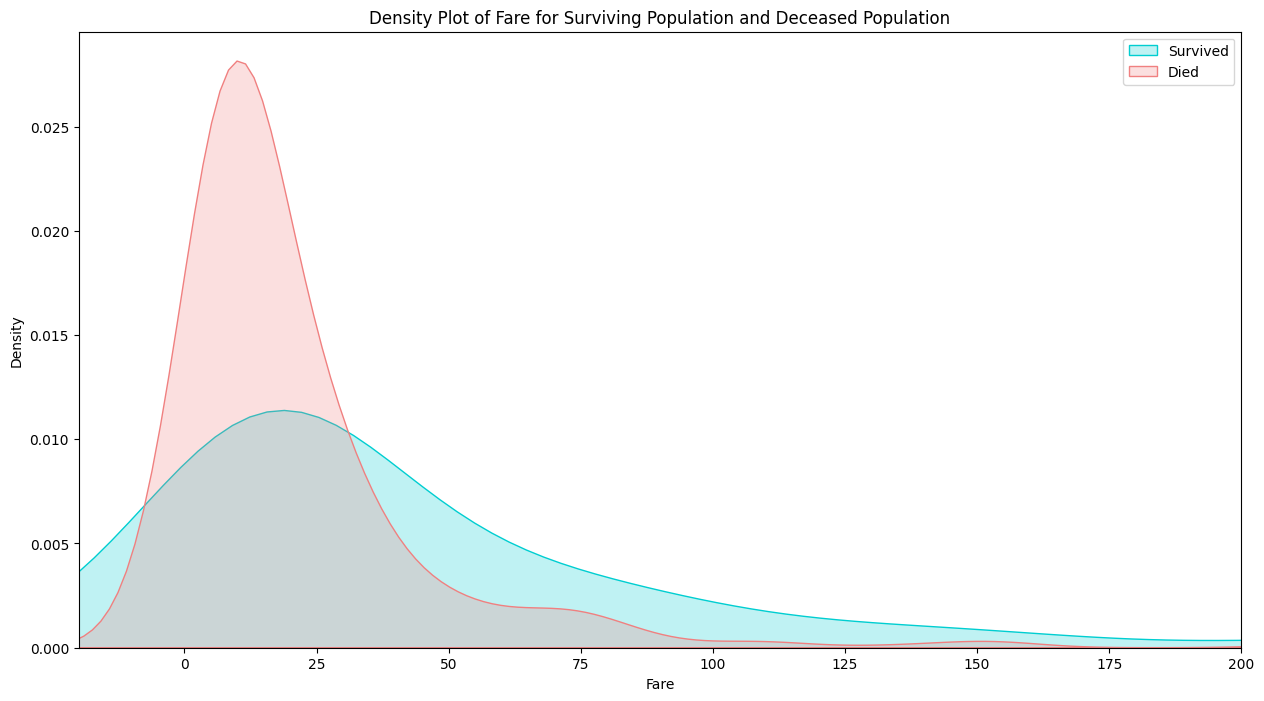

In [194]:
plt.figure(figsize=(15,8))
ax = sns.kdeplot(final_train["Fare"][final_train.Survived == 1], color="darkturquoise", shade=True)
sns.kdeplot(final_train["Fare"][final_train.Survived == 0], color="lightcoral", shade=True)
plt.legend(['Survived', 'Died'])
plt.title('Density Plot of Fare for Surviving Population and Deceased Population')
ax.set(xlabel='Fare')
plt.xlim(-20,200)
plt.show()

Pclass存活分析

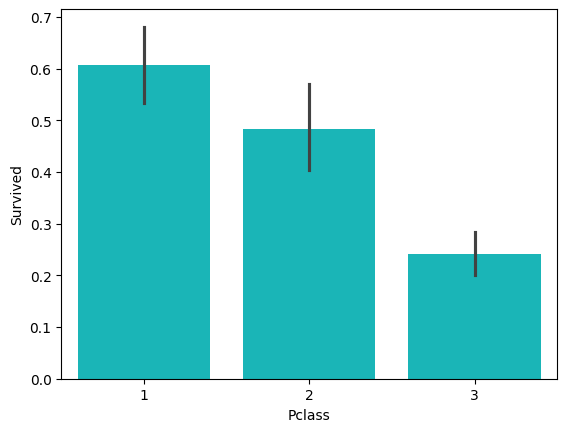

In [195]:
sns.barplot(x="Pclass", y="Survived", data=final_train, color="darkturquoise")
plt.show()

Embarked存活分析

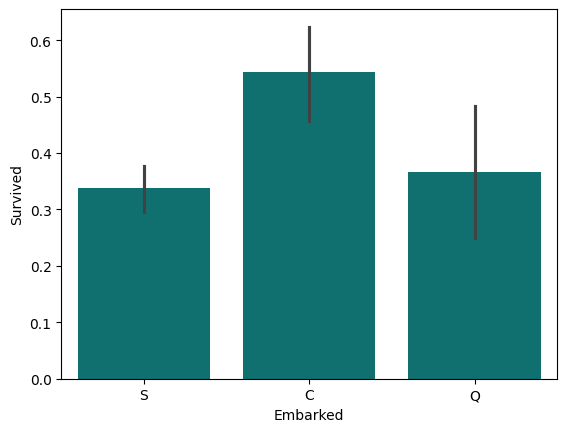

In [196]:
sns.barplot(x="Embarked", y="Survived", data=final_train,color="teal")
plt.show()

Sex存活分析

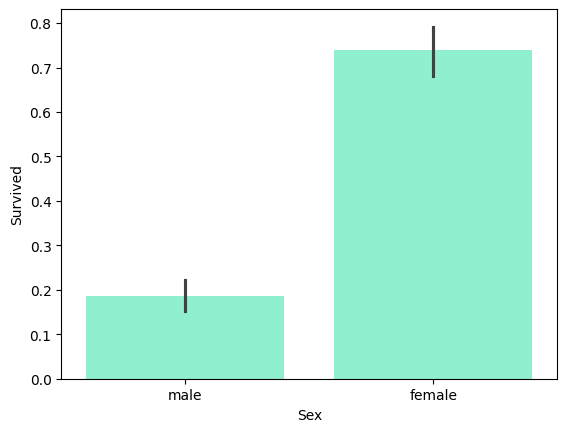

In [197]:
sns.barplot(x="Sex", y="Survived", data=final_train, color="aquamarine")
plt.show()

In [202]:
#將X_train內容換為編碼後資料
X_train = training

## 測試資料處理

In [203]:
#移除Age欄位有空值的資料
final_test = pd.concat([X_test, y_test], axis=1)
final_test.dropna(subset=['Age'], inplace=True)
final_test.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,102


In [204]:
X_test = final_test[feature_cols]
X_test=pd.get_dummies(X_test, columns=["Pclass","Embarked","Sex"])
y_test = final_test['Survived']

In [205]:
print(X_test.shape)
print(y_test.shape)

(142, 12)
(142,)


In [206]:
X_train

,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
331,45.5,0,0,28.5000,True,False,False,False,False,True,False,True
733,23.0,0,0,13.0000,False,True,False,False,False,True,False,True
382,32.0,0,0,7.9250,False,False,True,False,False,True,False,True
704,26.0,1,0,7.8542,False,False,True,False,False,True,False,True
813,6.0,4,2,31.2750,False,False,True,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
106,21.0,0,0,7.6500,False,False,True,False,False,True,True,False
270,28.0,0,0,31.0000,True,False,False,False,False,True,False,True
860,41.0,2,0,14.1083,False,False,True,False,False,True,False,True
435,14.0,1,2,120.0000,True,False,False,False,False,True,True,False


## 建立 LogisticRegression 模型

In [208]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Build a logreg and compute the feature importances
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

### 模型準確率

In [209]:
print('模型訓練準確率 {0:0.4f}'. format(accuracy_score(y_train, y_train_pred)))
print('模型測試準確率 {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

模型訓練準確率 0.8062
模型測試準確率 0.8028


### 模型評估報告

In [210]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         0.0       0.81      0.87      0.84        84
         1.0       0.79      0.71      0.75        58

    accuracy                           0.80       142
   macro avg       0.80      0.79      0.79       142
weighted avg       0.80      0.80      0.80       142



### 模型混淆矩陣

In [211]:
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[73 11]
 [17 41]]


#### 模型預測混淆矩陣圖

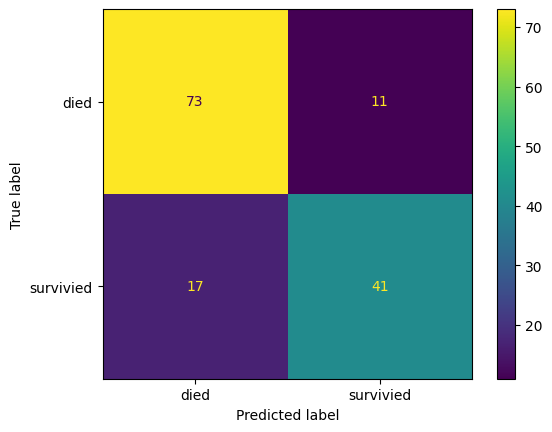

In [212]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['died','survivied'])
plt.show()

### 建立ROC圖

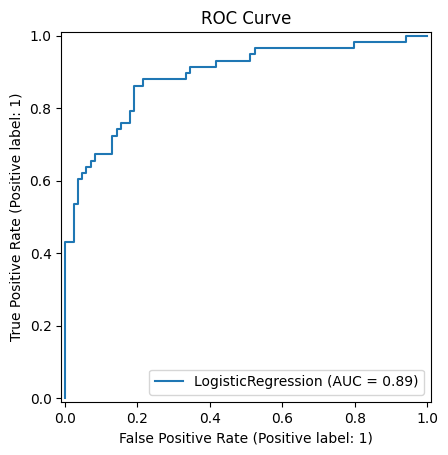

In [215]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

### 計算AUC值

In [214]:
y_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f"AUC: {auc:.2f}")

AUC: 0.89
